# Analyzing Car Prices Using Specifications and Features

![Banner](./assets/banner.jpeg)

## Topic
*What problem are you (or your stakeholder) trying to address?*
📝 <!-- Answer Below -->

Can we predict vehicle prices based on specifications, features, and market factors?

## Project Question
*What specific question are you seeking to answer with this project?*
*This is not the same as the questions you ask to limit the scope of the project.*
📝 <!-- Answer Below -->

Which vehicle specifications and features have the greatest impact on car prices?

## What would an answer look like?
*What is your hypothesized answer to your question?*
📝 <!-- Answer Below -->

Car prices will most likely increase as horsepower, engine size, vehicle weight, and  higher horsepower, larger engines, heavier vehicle weight, and the presence of premium or safety features. I expect horsepower and brand/trim level to have the strongest impact on price, while factors like fuel economy may have a smaller effect. The final answer would show measurable relationships and identify which variables most strongly predict price.

## Data Sources
*What 3 data sources have you identified for this project?*
*How are you going to relate these datasets?*
📝 <!-- Answer Below -->


1. CSV: https://www.kaggle.com/datasets/metawave/vehicle-price-prediction
   Contains vehicle specs like engine size, horsepower, weight, and base price.

2. CSV: https://www.kaggle.com/datasets/makslypko/large-cars-dataset
    Includes additional features, trims, and other specifications.

3. API: Kelly Blue Book API
    Provides real-world market prices for each vehicle.

## Approach and Analysis
*What is your approach to answering your project question?*
*How will you use the identified data to answer your project question?*
📝 <!-- Start Discussing the project here; you can add as many code cells as you need -->

Step 1: Manipulation: Merge the two CSVs and API using make, model, year, and trim so each car has specs, features, and price on one table.

Step 2: Exploring: Check for missing data and find basic stats for variables like horsepower, weight, and price.

Step 3: Analyzing: See which features or specifications relate most to the price.

Step 4: Modeling: Build data visualations to show price predictions and dentify which features play the biggest roles.

Step 5: Summarize: Aggregate the findings into a report format to showcase the results.

## Data Imports, Quality Analysises, and Cleaning

In [89]:
# Start your code here
import pandas as pd
import numpy as np
from scipy.stats import trim_mean
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from wordcloud import WordCloud
%matplotlib inline

In [90]:
df1 = pd.read_csv("large cars dataset.csv")
df2 = pd.read_csv("vehicle_price_prediction.csv")

df1.head()
df2.head()

,year,make,model,engine_hp,transmission,fuel_type,body_type,price
0,2016,Volkswagen,Jetta,173,Manual,Electric,Sedan,7208.52
1,2010,Lexus,RX,352,Manual,Gasoline,Sedan,6911.81
2,2016,Subaru,Crosstrek,188,Automatic,Diesel,Sedan,11915.63
3,2016,Cadillac,Lyriq,338,Manual,Gasoline,SUV,25984.79
4,2018,Toyota,Highlander,196,Manual,Diesel,Sedan,8151.30


In [91]:
#dataset 1 quality analysis
df1.info()
df1.describe()
df1.isnull().sum()
df1.duplicated().sum()

<class 'pandas.DataFrame'>
RangeIndex: 428 entries, 0 to 427
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Brand         428 non-null    str    
 1   Model         428 non-null    str    
 2   VehicleClass  428 non-null    str    
 3   Region        428 non-null    str    
 4   DriveTrain    428 non-null    str    
 5   MSRP          428 non-null    str    
 6   DealerCost    428 non-null    str    
 7   EngineSize    428 non-null    float64
 8   Cylinders     426 non-null    float64
 9   HorsePower    428 non-null    int64  
 10  MPG_City      428 non-null    int64  
 11  MPG_Highway   428 non-null    int64  
 12  Weight        428 non-null    int64  
 13  Wheelbase     428 non-null    int64  
 14  Length        428 non-null    int64  
dtypes: float64(2), int64(6), str(7)
memory usage: 71.3 KB


np.int64(0)

In [92]:
#dataset 2 quality analysis
df2.info()
df2.describe()
df2.isnull().sum()
df2.duplicated().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 8 columns):
 #   Column        Non-Null Count    Dtype  
---  ------        --------------    -----  
 0   year          1000000 non-null  int64  
 1   make          1000000 non-null  str    
 2   model         1000000 non-null  str    
 3   engine_hp     1000000 non-null  int64  
 4   transmission  1000000 non-null  str    
 5   fuel_type     1000000 non-null  str    
 6   body_type     1000000 non-null  str    
 7   price         1000000 non-null  float64
dtypes: float64(1), int64(2), str(5)
memory usage: 91.3 MB


np.int64(2099)

In [93]:
#dataset cleaning
df1 = df1.drop_duplicates()
df1['Cylinders'] = df1['Cylinders'].fillna(0).astype(int)
df1['EngineSize'] = df1['EngineSize'].astype(int)
df1 = df1.dropna()


df2 = df2.drop_duplicates()
df2 = df2[df2['price'] < df2['price'].quantile(0.99)]
df2 = df2[df2['engine_hp'] < df2['engine_hp'].quantile(0.99)]
df2 = df2.dropna()

## Visualizations

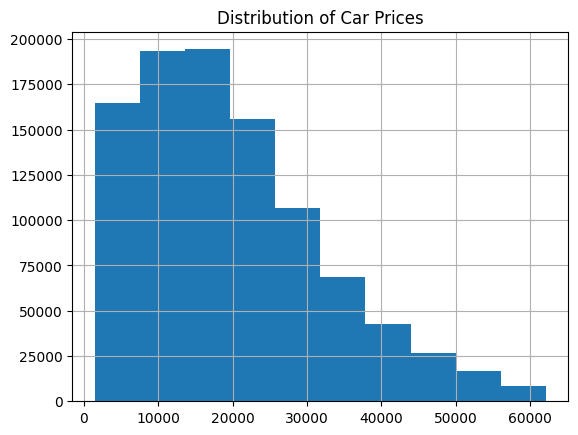

In [94]:
# Visualization 1: Distribution of Car Prices
df2['price'].hist()
plt.title("Distribution of Car Prices")
plt.show()

This shows the distribution of car prices. Most cars are in the lower price range.

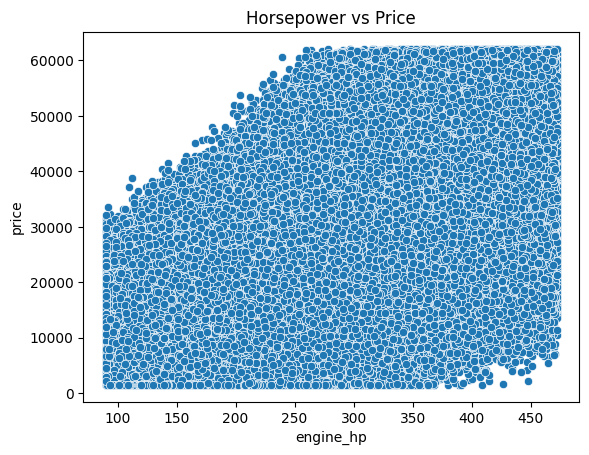

In [95]:
# Visualization 2: Relationship between Horsepower and Price
sns.scatterplot(x='engine_hp', y='price', data=df2)
plt.title("Horsepower vs Price")
plt.show()

This shows the relationship between engine horsepower and price. Vehicles with higher engine horsepower tend to have higher prices, though the relationship is not perfectly linear except on the far ends of all spectrums. This is a positive result coorelation still.

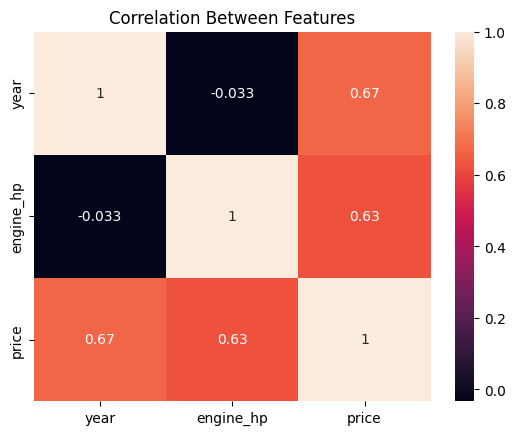

In [96]:
# Visualization 3: Correlation Heatmap
sns.heatmap(df2.corr(numeric_only=True), annot=True)
plt.title("Correlation Between Features")
plt.show()

This heatmap shows correlations between numeric variables. Price has a stronger relationship with engine horsepower compared to other features, while vehicle year shows a weaker relationship.

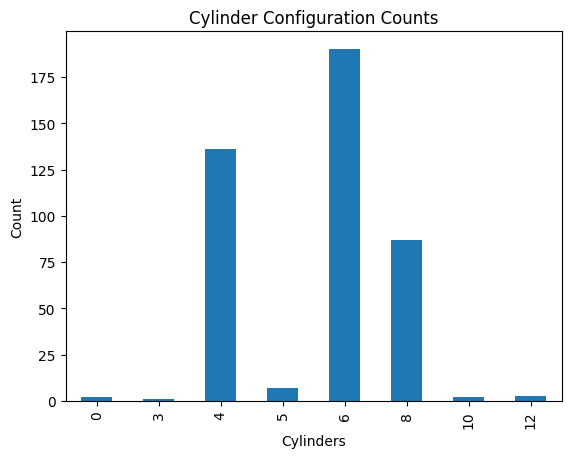

In [97]:
# Visualization 4: Cylinder Configuration Counts
df1['Cylinders'].value_counts().sort_index().plot(kind='bar')
plt.title("Cylinder Configuration Counts")
plt.xlabel("Cylinders")
plt.ylabel("Count")
plt.show()

Most vehicles in the dataset have 6-cylinder engines, followed by 4-cylinder and 8-cylinder configurations. This suggests mid-range engine sizes are the most common in the market.

## Exploratory Data Analysis (EDA)

### Statistical Summaries
Summary statistics were generated using the describe() function. These showed the central tendencies and spread of numeric variables such as price and engine horsepower. The price variable shows a wide range, indicating significant variation in vehicle values.

### Data Distributions
Visualizations such as histograms and bar charts were used to analyze data distributions. The price distribution is right-skewed, meaning most vehicles fall in lower to mid price ranges. Cylinder counts show that 6-cylinder vehicles are the most common, followed by 4-cylinder and 8-cylinder configurations.

### Correlations Between Features
A correlation heatmap was used to analyze relationships between numeric variables. Engine horsepower shows a positive relationship with price, while other variables such as year show weaker correlations.

### Data Issues Identified
Missing values and duplicate records were identified during inspection. These were handled during the cleaning phase. Outliers in price and engine horsepower were also removed to reduce skew in the dataset.

### Data Type Conversions
Cylinders were converted to integer values for consistency in analysis. This ensures proper grouping and visualization of engine configurations.

## Machine Learning

I plan to use regression to predict car prices based on features such as engine horsepower, vehicle year, and fuel type. A challenge may be handling outliers and selecting the most relevant features.

## Resources and References
*What resources and references have you used for this project?*
📝 <!-- Answer Below -->

In [98]:
# ⚠️ Make sure you run this cell at the end of your notebook before every submission!
!jupyter nbconvert --to python source.ipynb

[NbConvertApp] Converting notebook source.ipynb to python
[NbConvertApp] Writing 1268 bytes to source.py
